In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [5]:
class AgentState(TypedDict):
    num1 : int
    num2 : int
    operator : str
    result : int

In [9]:
def addition(state : AgentState) -> AgentState:
    state['result'] = state['num1'] + state['num2']
    return state
def subtraction(state : AgentState) -> AgentState:
    state['result'] = state['num1'] - state['num2']
    return state
def conditional_node(state : AgentState) -> AgentState:
    return state
def decider_function(state : AgentState) -> str:
    if state["operator"] == "+":
        return "addition_edge"
    else:
        return "subtraction_edge" 

In [11]:
graph = StateGraph(AgentState)
graph.add_node("add_node", addition)
graph.add_node("subtract_node", subtraction)
graph.add_node("conditional_node", conditional_node)

graph.set_entry_point("conditional_node")

graph.add_conditional_edges(
    "conditional_node",
    decider_function,
    {
        "addition_edge" : "add_node",
        "subtraction_edge" : "subtract_node"
    }
)

graph.set_finish_point("add_node")
graph.set_finish_point("subtract_node")
app = graph.compile()

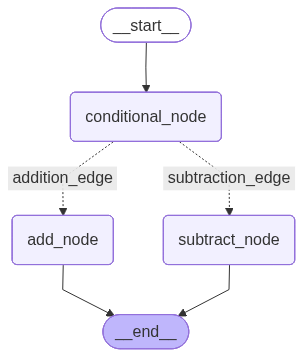

In [12]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
app.invoke({
    'num1' : 10,
    'num2' : 15,
    'operator' : '+'
})

{'num1': 10, 'num2': 15, 'operator': '+', 'result': 25}